# Pipeline status — what is running, what is done

Run the cells to get live state instead of reading a summary. Needs an SSH master:

```bash
ssh -MNf savio-login          # in your own terminal; needs PIN+OTP
```

**One rule:** run these cells one at a time. Concurrent SSH exhausts the login node's session
limit, and the error it produces (`Permission denied`) *looks* like an expired login but isn't.

In [1]:
import subprocess, textwrap

def savio(cmd, timeout=90):
    "Run one command on Savio. Returns stdout, or an explanation if we cannot connect."
    r = subprocess.run(["ssh", "-o", "ConnectTimeout=20", "-o", "BatchMode=yes",
                        "savio-login", cmd], capture_output=True, text=True, timeout=timeout)
    if r.returncode != 0:
        chk = subprocess.run(["ssh", "-O", "check", "savio-login"],
                             capture_output=True, text=True)
        hint = ("master is RUNNING -> this is session exhaustion, wait and retry"
                if "running" in chk.stderr.lower() + chk.stdout.lower()
                else "no control socket -> run:  ssh -MNf savio-login")
        return f"[could not connect]  {hint}\n{r.stderr.strip()[:200]}"
    return r.stdout

print(savio("echo connected: $(hostname)"))

connected: ln003.brc



## Jobs — queue and recent history

In [2]:
print("QUEUE")
print(savio('squeue -u jonathanswang -o "%.12i %.16j %.11P %.10T %.10M %.11l %R"'))
print("\nRECENT (last 3 days)")
print(savio('sacct -u jonathanswang -S $(date -d "3 days ago" +%F) '
            '--format=JobID%13,JobName%20,State%12,Elapsed,End%17 -X'))

QUEUE


       JOBID             NAME   PARTITION      STATE       TIME  TIME_LIMIT NODELIST(REASON)
    39164203     hubert_run15  savio4_gpu    RUNNING    3:32:05    12:00:00 n0388.savio4


RECENT (last 3 days)


        JobID              JobName        State    Elapsed               End 
------------- -------------------- ------------ ---------- ----------------- 
     36094638         hubert_iter2 CANCELLED b+   00:00:00 ################# 
     39047884      combined_corpus       FAILED   00:00:01 ################# 
     39114877      combined_corpus    COMPLETED   02:18:37 ################# 
     39132082         hubert_run15    PREEMPTED   00:46:57 ################# 
     39164203         hubert_run15      RUNNING   03:32:06           Unknown 



## run15 — the de-confounding experiment

**What it is.** Every `run11` vs AVES comparison so far is confounded: run11 saw 116 h of zebra
finch with k=100 labels; AVES saw 360 h of general audio with k=200 labels. **Corpus and label
recipe always moved together**, so "AVES wins" has never been attributable to either one.

run15 changes *only* the corpus and the vocabulary, holding every other knob at run11's value.

| | run11 | run15 |
|---|---|---|
| corpus | 116.0 h, ZF only | **224.42 h**, ZF + FSD50K |
| vocabulary | k=100 | **k=200** |
| learning rate | 1e-4 | 1e-4 |
| updates | 93,750 | 93,750 |
| seconds of audio per step | 80.2 | **80.5** ← effective batch matched |
| epochs | 18.0 | 9.35 |

Fixed **compute**, not fixed epochs — on purpose. The question that binds is: *at the same budget,
does a bigger corpus help?*

In [3]:
EXP = "/global/scratch/users/jonathanswang/temp_train_run15_combined"
out = savio(f'''
CK={EXP}/checkpoints_ZF_test_pipeline_hubert_pretrain_base
M=$(ls -t {EXP}/lightning_logs/version_*/metrics.csv 2>/dev/null | head -1)
echo "checkpoints:"; ls $CK 2>/dev/null | tail -4 || echo "  none yet"
echo "metrics rows: $(wc -l < $M 2>/dev/null || echo 0)"
[ -f $M ] && awk -F, 'NR>1 && $5!=""{{s=$5}} END{{print "last step: " s " of 93750"}}' $M
''')
print(out)

checkpoints:
epoch=5-step=60170.ckpt
epoch=6-step=70198.ckpt
epoch=7-step=80228.ckpt
last.ckpt
metrics rows: 1434
last step: 81249 of 93750



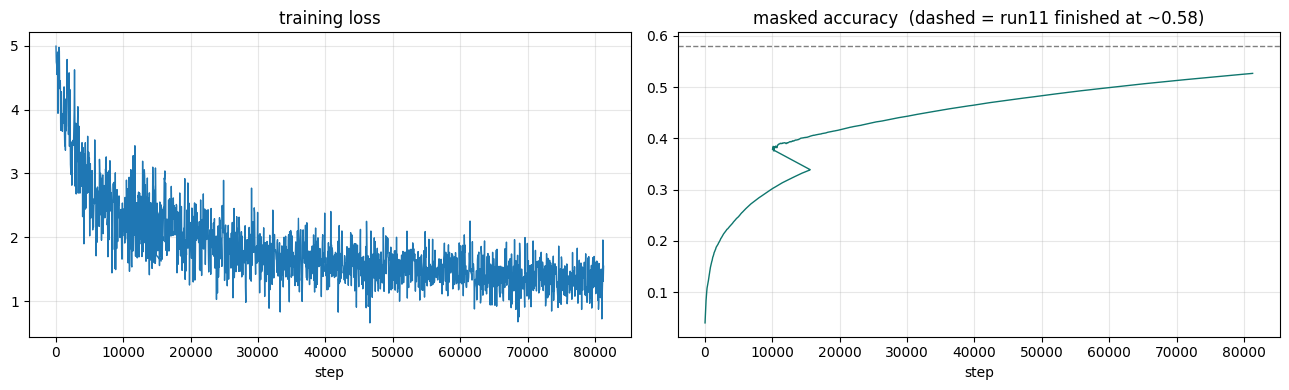

last step 81249 of 93750


In [4]:
# Training curve, if metrics.csv has anything yet.
import io, pandas as pd, matplotlib.pyplot as plt

# a resumed run writes a NEW version_* dir, so concatenate them all in order
csv = savio(f"for f in $(ls -v {EXP}/lightning_logs/version_*/metrics.csv 2>/dev/null); do "
            f"cat $f; done || true")
if csv.strip() and not csv.startswith("[could not connect]"):
    lines = [l for l in csv.splitlines() if l.strip()]
    hdr = lines[0]
    body = [l for l in lines[1:] if l != hdr]          # drop repeated headers from each version
    df = pd.read_csv(io.StringIO("\n".join([hdr] + body)))
    acc = df.dropna(subset=["train_masked_accuracy_step"])
    loss = df.dropna(subset=["train_loss_step"])
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(loss["step"], loss["train_loss_step"], lw=1)
    ax[0].set_title("training loss"); ax[0].set_xlabel("step")
    ax[1].plot(acc["step"], acc["train_masked_accuracy_step"], lw=1, color="#0F766E")
    ax[1].axhline(0.58, ls="--", color="grey", lw=1)
    ax[1].set_title("masked accuracy  (dashed = run11 finished at ~0.58)")
    ax[1].set_xlabel("step")
    for a in ax: a.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print(f"last step {int(df['step'].max())} of 93750")
else:
    print("no metrics yet —", csv[:160])

## Corpus — already built and verified

Job 39114877, `COMPLETED` in 2 h 19 m. A SLURM `COMPLETED` has lied in this project before, so
these were checked rather than assumed.

In [5]:
DATA = "/global/scratch/users/jonathanswang/temp_files/combined_zf_fsd/data/spectrogram"
print(savio(f'''
echo "files in TSV:  $(( $(wc -l < {DATA}/tsv/ZF_test_pipeline_train.tsv) - 1 ))"
echo "label file:    $(stat -c %s {DATA}/label/label_train.pt) bytes"
echo "kmeans model:  $(stat -c %s {DATA}/km_model/model.pt) bytes"
echo "sources:"
awk 'NR>1{{split($1,a,"/"); print "   " a[1]}}' {DATA}/tsv/ZF_test_pipeline_train.tsv | sort | uniq -c
'''))

files in TSV:  763
label file:    323354746 bytes
kmeans model:  3201170 bytes
sources:
    478    fsd50k_dev
    165    replay_fsd50k
    120    run5-4-26-full



Verified at build time:

- **763 files, 224.42 h** — ZF 120 (116.0 h) + FSD-dev 478 (80.6 h) + FSD-eval 165 (27.9 h)
- **40,395,592 label frames at exactly 50.00 fps** — frame count and audio duration agree, which is
  the real proof the labelling covered everything
- **all 763 TSV rows resolve**, zero missing, zero frame-count mismatch
- all 200 clusters populated

And a control that changed how to read it — the new codebook is **healthier** than run11's:

| | k | perplexity | entropy efficiency | largest cluster |
|---|---|---|---|---|
| combined | 200 | **75.7** | **0.817** | 9.41% |
| run11 | 100 | 31.8 | 0.751 | 17.87% |

*Perplexity* = the effective number of clusters actually in use. More than doubling it is the
payoff you want from k=100→200 — the labels carry more information, not just more bins.

## Disk — 615 GB of intermediates still parked

In [6]:
print(savio("du -sh /global/scratch/users/jonathanswang/temp_files/"
            "{zf_feat_rebuild,fsd50k_dev,replay_fsd50k,combined_zf_fsd} 2>/dev/null; "
            "echo; df -BG /global/scratch | tail -1"))

312G	/global/scratch/users/jonathanswang/temp_files/zf_feat_rebuild
225G	/global/scratch/users/jonathanswang/temp_files/fsd50k_dev
78G	/global/scratch/users/jonathanswang/temp_files/replay_fsd50k
318M	/global/scratch/users/jonathanswang/temp_files/combined_zf_fsd

10.5.250.22@o2ib,10.5.250.23@o2ib,10.5.250.24@o2ib,10.5.250.25@o2ib:/brc 12419467G 10577066G  1712046G  87% /global/scratch



Those feature trees are dead weight now — training reads **audio + labels**, not features. Deleting
frees ~615 GB; keeping them saves 2 h 19 m if we ever refit k-means at a different `k`. With 1.7 PB
free there is no pressure either way.

```bash
# only when you want the space back
rm -rf /global/scratch/users/jonathanswang/temp_files/{zf_feat_rebuild,fsd50k_dev,replay_fsd50k,combined_zf_fsd}/data/spectrogram/feat
```

## Task board

| # | task | state |
|---|---|---|
| 30 | AVES-as-label-teacher on ZF | pending |
| 32 | Build combined ZF+FSD50K corpus | **done** — job 39114877, verified |
| 33 | Train iteration 1 on combined corpus | **running** — run15 |
| 34 | Iteration-2 labels from layer 6, retrain | blocked on 33 |